# 09. 이미지 분류와 CNN 입문

이번 노트북에서는 작은 손글씨 숫자 이미지를 CNN으로 분류합니다.

데이터는 scikit-learn의 `load_digits()`를 사용합니다. 이미 설치된 작은 데이터라 CPU에서도 빠르게 실습할 수 있습니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits  # 작은 손글씨 숫자 이미지 데이터를 불러오는 함수입니다.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from keras.callbacks import EarlyStopping

## 1. 데이터 불러오기

`load_digits()` 데이터는 8x8 흑백 숫자 이미지입니다.

In [2]:
digits = load_digits()

images = digits.images  # 이미지 데이터입니다. 모양은 (샘플 수, 높이, 너비)입니다.
labels = digits.target  # 정답 숫자입니다. 0부터 9까지 있습니다.

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("클래스:", np.unique(labels))

images shape: (1797, 8, 8)
labels shape: (1797,)
클래스: [0 1 2 3 4 5 6 7 8 9]


## 2. 이미지 확인하기

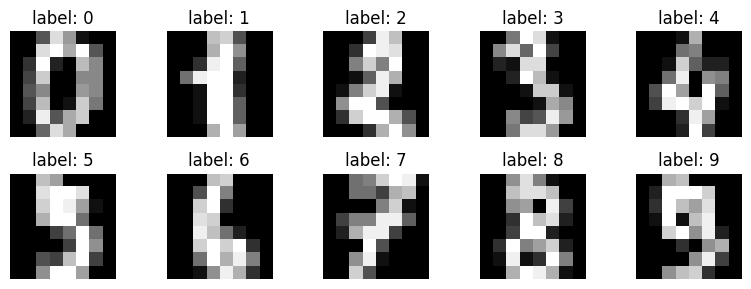

In [3]:
plt.figure(figsize=(8, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"label: {labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. 전처리

CNN은 이미지 입력을 보통 `(샘플 수, 높이, 너비, 채널 수)` 형태로 받습니다.

현재 데이터는 `(샘플 수, 8, 8)`이므로 마지막에 채널 차원 1개를 추가합니다.

In [4]:
# 픽셀값은 0~16 범위입니다. 16으로 나누어 0~1 사이로 맞춥니다.
X = images.astype("float32") / 16.0

# 흑백 이미지이므로 채널 수 1을 마지막 차원에 추가합니다.
# reshape의 -1은 샘플 수를 자동으로 맞추라는 뜻입니다.
X = X.reshape(-1, 8, 8, 1)

y = labels

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1797, 8, 8, 1)
y shape: (1797,)


## 4. 학습/검증 데이터 나누기

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1437, 8, 8, 1)
X_val: (360, 8, 8, 1)
y_train: (1437,)
y_val: (360,)


## 5. CNN 모델 만들기

이번 모델의 흐름은 다음과 같습니다.

```text
Conv2D -> MaxPooling2D -> Flatten -> Dense -> Softmax 출력
```

In [6]:
model = Sequential([
    Input(shape=(8, 8, 1)),  # 8x8 흑백 이미지 1장을 입력으로 받습니다.
    Conv2D(16, kernel_size=(3, 3), activation="relu"),  # 3x3 필터 16개로 이미지 특징을 찾습니다.
    MaxPooling2D(pool_size=(2, 2)),  # 2x2 영역에서 가장 큰 값만 남겨 크기를 줄입니다.
    Flatten(),  # 2차원 특징 맵을 Dense 층에 넣기 위해 1차원으로 펼칩니다.
    Dense(32, activation="relu"),  # 분류를 위한 은닉층입니다.
    Dense(10, activation="softmax")  # 숫자 0~9, 총 10개 클래스 확률을 출력합니다.
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,130 (20.04 KB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. 컴파일하기

정답 라벨이 0~9 정수이므로 `sparse_categorical_crossentropy`를 사용합니다.

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 7. 학습하기

In [8]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

print("실제로 학습한 epoch 수:", len(history.history["loss"]))

실제로 학습한 epoch 수: 30


## 8. 학습 곡선 확인하기

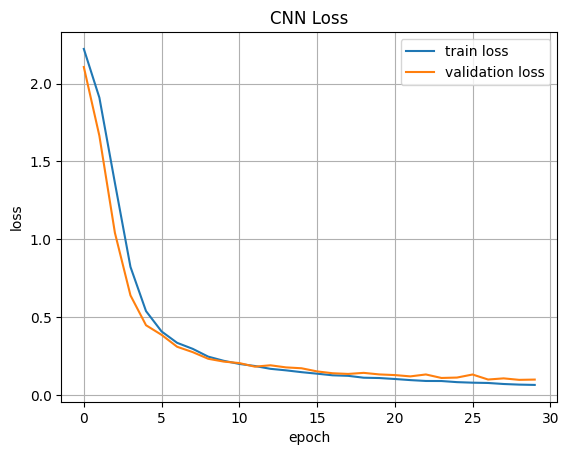

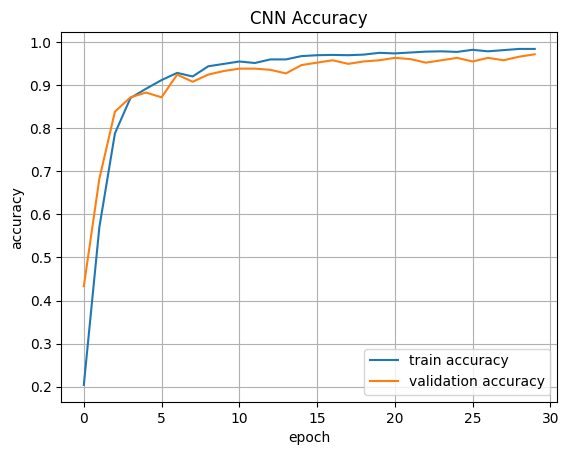

In [9]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("CNN Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("CNN Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 9. 검증 데이터 예측하기

softmax 출력은 클래스별 확률입니다.

`argmax`를 사용하면 확률이 가장 높은 클래스 번호를 고를 수 있습니다.

In [10]:
probs = model.predict(X_val, verbose=0)
y_pred = np.argmax(probs, axis=1)

print("첫 번째 샘플의 클래스별 확률:")
print(probs[0])
print("예측 라벨:", y_pred[0])
print("실제 라벨:", y_val[0])

첫 번째 샘플의 클래스별 확률:
[2.7824626e-03 1.8674031e-07 6.0799664e-07 4.4404213e-05 2.9205290e-07
 9.9335265e-01 4.4724362e-05 2.6210419e-06 2.9129672e-04 3.4808503e-03]
예측 라벨: 5
실제 라벨: 5


## 10. 평가하기

In [11]:
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print()
print("Classification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.9666666666666667
Confusion Matrix:
[[35  0  0  0  1  0  0  0  0  0]
 [ 0 34  0  0  0  0  0  0  0  2]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 36  0  1  0  0  0  0]
 [ 0  0  0  0 35  0  1  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 34  0  2  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  2  0  0  0  0  0  1 32  0]
 [ 0  0  0  0  2  0  0  0  0 34]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.94      0.94      0.94        36
           2       1.00      1.00      1.00        35
           3       1.00      0.97      0.99        37
           4       0.92      0.97      0.95        36
           5       0.97      1.00      0.99        37
           6       0.97      0.94      0.96        36
           7       0.97      1.00      0.99        36
           8       0.94      0.91      0.93        35
           9       0.94      0.94      0.94        36

  

## 11. 예측 결과 눈으로 보기

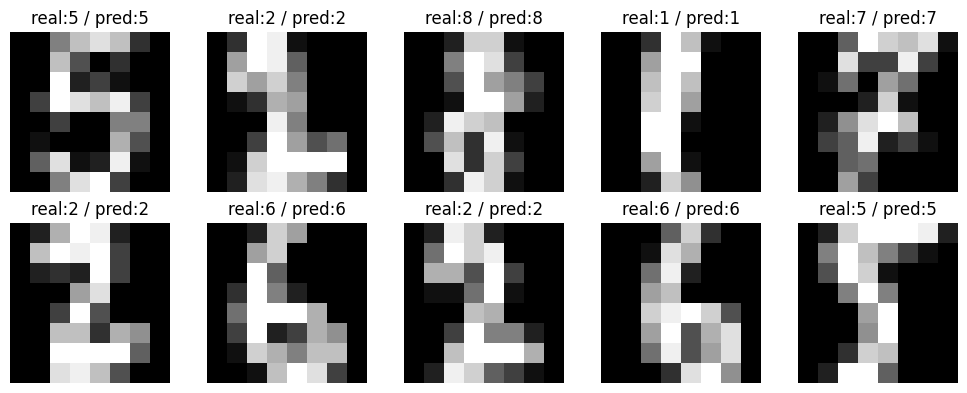

In [12]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_val[i].reshape(8, 8), cmap="gray")
    plt.title(f"real:{y_val[i]} / pred:{y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 정리

이번 장에서는 이미지 데이터를 CNN에 넣기 위한 기본 흐름을 배웠습니다.

```text
이미지 모양 확인
채널 차원 추가
Conv2D로 특징 추출
MaxPooling2D로 크기 축소
Flatten으로 펼치기
Dense와 softmax로 분류
```